In [50]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [51]:
data_path = "OneDrive_3_10-3-2025"

In [52]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [53]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-16 to 3-22-25 (45326, 8)
2 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-30 to 4-5-25 (45072, 8)
3 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-13 to 4-19-25 (41088, 8)
4 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-20 to 4-26-25 (46686, 8)
5 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-27 to 5-3-25 (44169, 8)
6 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-6 to 4-12-25 (46630, 8)
7 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-11 to 5-17-25 (43268, 8)
8 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-18 to 5-24-25 (45104, 8)
9 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-25 to 5-31-25 (36851, 8)
10 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-4 to 5-10-25 (43955, 8)
11 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-1 to 6-7-25 (44523, 8)
12 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-15 to 6-21-25 (37234, 8)
13 CAR - EP, Flow, Activity, Queue, &amp; A

In [54]:
df_main['Activity Start Timestamp'] = pd.to_datetime(df_main['Activity Start Timestamp'], errors='coerce')

In [55]:
# Basic overview of 'EP Name' values
df_main['EP Name'].value_counts(dropna=False)

EP Name
Main Number Telephony EP                    445983
NaN                                         312347
Legal Menu Telephony EP                      92192
Pre-Legal Menu Seniors Menu Telephony EP     87087
Closed Queue Menu Telephony EP               62244
All LAC Queues Telephony EP                  54574
Courtesy Callback Telephony EP               38286
Closed Hours-Holidays Menu Telephony EP      27779
Other Legal Menu Telephony EP                27763
Legal Housing Menu Telephony EP              26564
Intake Outdial EP                            22741
Farmworker Main Number Telephony EP          22363
Legal Family Menu Telephony EP               22321
Legal Benefits Menu Telephony EP              3081
Legal HIV Menu Telephony EP                   2875
Legal Immigration Menu Telephony EP           2630
Legal Employment Menu Telephony EP            2250
Name: count, dtype: int64

In [56]:
# Create a smaller DataFrame for only Pre legal seniors Menu data
df_prelegal_seniors_only = df_main[df_main['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'].copy()

In [57]:
# Step 1: Get all unique Contact Session IDs that went through the seniors menu
senior_sessions = df_prelegal_seniors_only['Contact Session ID'].unique()

# Step 2: Filter df_main to only include those same sessions
df_senior_fullpath = df_main[df_main['Contact Session ID'].isin(senior_sessions)].copy()

# Step 3: sort chronologically to see the call flow order
df_seniors = df_senior_fullpath.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
).reset_index(drop=True)

In [58]:
# Identify the last EP Name per Contact Session ID
last_ep = (
    df_seniors.groupby('Contact Session ID')['EP Name']
    .last()
    .reset_index()
    .rename(columns={'EP Name': 'Last_EP_Name'})
)

# Merge that back to the main df_benefits
df_seniors = df_seniors.merge(last_ep, on='Contact Session ID', how='left')

# Create Yes/No or 1/0 indicator
df_seniors['Ended_in_PreLegalSeniors_EP'] = np.where(
    df_seniors['Last_EP_Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP', 'Yes', 'No'
)

In [59]:
df_seniors['Contact Session ID'].nunique()

41458

In [60]:
# For each Contact Session ID, take the last non-null Activity Name
df_seniors['Last_NonNull_Activity'] = (
    df_seniors
      .groupby('Contact Session ID')['Activity Name']
      .transform(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan)
)

In [61]:
# 1) Get unique Contact Session ID + their last non-null activity
last_activity_per_session = (
    df_seniors[['Contact Session ID', 'Last_NonNull_Activity']]
    .drop_duplicates(subset='Contact Session ID')
)

# 2) Count how many sessions ended in each activity
activity_end_counts = (
    last_activity_per_session['Last_NonNull_Activity']
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={'index': 'Activity Name', 'Last_NonNull_Activity': 'Unique Contact Sessions'})
)

In [62]:
activity_end_counts

,Unique Contact Sessions,count
0,ClosedQueueMenu,14892
1,LegalMenu2,4290
2,ClinicVoicemailTransfer,4062
3,LegalServerScreenPop,3825
4,OtherLegalMenu,2415
...,...,...
59,AddressFaxHoursMenu,1
60,GetLoggedInSubSeniorOtherAgents,1
61,PlayCCBConfirmation,1
62,GetLoggedInOtherSubSeniorsAgents,1


In [63]:
# Filter only calls that ended in the Pre-Legal Seniors EP
df_prelegal_ended = df_seniors[df_seniors['Ended_in_PreLegalSeniors_EP'] == 'Yes']

# Get value counts of their final activity
activity_counts = df_prelegal_ended['Last_NonNull_Activity'].value_counts()

activity_counts


Last_NonNull_Activity
SeniorsMenu                3506
DisconnectContact1         2196
SeniorsADAPTMenu           2171
SuburbanSeniorsMenu        1820
SuburbsOrCityMenu          1740
ThankYouGoodbye            1098
SeniorsConfirmationMenu     943
DisconnectContact2          742
SeniorNotCookCoMenu         638
OtherLegalOtherMenu         245
PreTenantMenu               244
LegalMenu2                   18
Name: count, dtype: int64

In [65]:
import pandas as pd

# ---- 1. Define activities that belong to the Pre-Legal Seniors menu ----
prelegal_activities = [
    'DisconnectContact1',
    'DisconnectContact2',
    'SeniorsMenu',
    'SeniorsADAPTMenu',
    'SuburbanSeniorsMenu',
    'SuburbsOrCityMenu',
    'ThankYouGoodbye',
    'SeniorsConfirmationMenu',
    'SeniorNotCookCoMenu',
    'OtherLegalOtherMenu',
    'PreTenantMenu',
    'LegalMenu2'
]

# ---- 2. All calls that passed through the Pre-Legal Seniors menu at any point ----
df_preseniors_passed = df_main[df_main['Activity Name'].isin(prelegal_activities)]
all_preseniors_calls = df_preseniors_passed['Contact Session ID'].nunique()

# ---- 3. Among calls that ENDED in the Pre-Legal Seniors EP ----
# (you already flagged these with Ended_in_PreLegalSeniors_EP in df_seniors)
df_preseniors_end = df_seniors[df_seniors['Ended_in_PreLegalSeniors_EP'] == 'Yes']

# ---- 4. Final activities that are considered "Abandoned" in this menu ----
abandoned_activities = [
    'SeniorsMenu',
    'SeniorsADAPTMenu',
    'SuburbanSeniorsMenu',
    'SuburbsOrCityMenu',
    'SeniorsConfirmationMenu',
    'OtherLegalOtherMenu',
    'PreTenantMenu',
    'LegalMenu2',
    'DisconnectContact1'
]

# Filter down to calls that ended in one of those abandoned activities
df_preseniors_abandoned = df_preseniors_end[
    df_preseniors_end['Last_NonNull_Activity'].isin(abandoned_activities)
]

num_abandoned_in_preseniors = df_preseniors_abandoned['Contact Session ID'].nunique()

# ---- 5. Compute percentage of all Pre-Legal Seniors callers who abandoned IN that menu ----
pct_abandoned_in_preseniors = round(
    num_abandoned_in_preseniors / all_preseniors_calls * 100, 2
)

print("Calls that passed through Pre-Legal Seniors menu:", all_preseniors_calls)
print("Calls abandoned IN Pre-Legal Seniors:", num_abandoned_in_preseniors)
print("Percent abandoned IN Pre-Legal Seniors:", pct_abandoned_in_preseniors, "%")


Calls that passed through Pre-Legal Seniors menu: 44555
Calls abandoned IN Pre-Legal Seniors: 1232
Percent abandoned IN Pre-Legal Seniors: 2.77 %


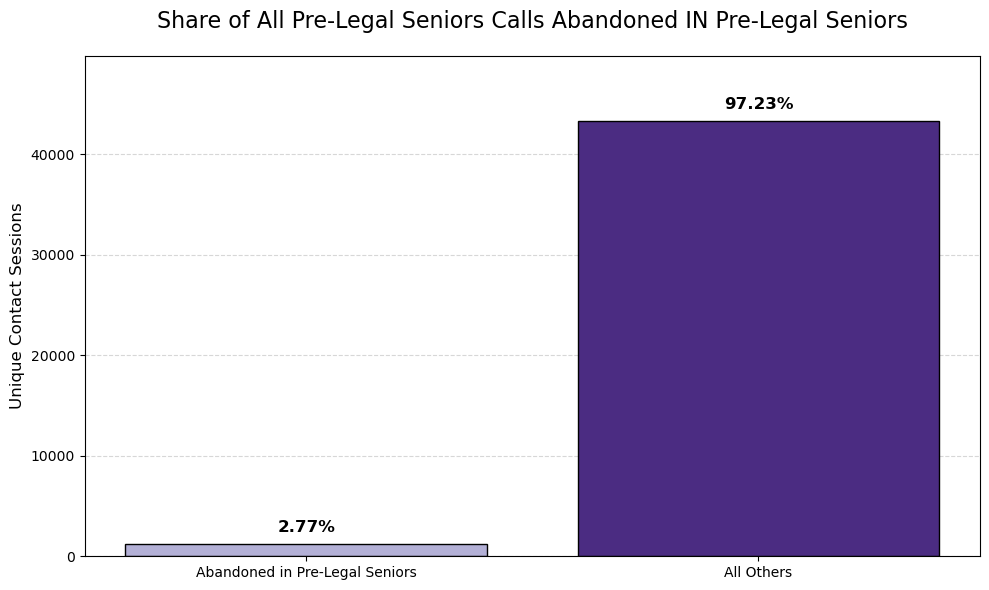

In [68]:
# ----- Bar chart: Share of Pre-Legal Seniors Calls Abandoned IN the Menu -----

# Compute "all others" and percentages
others_preseniors = all_preseniors_calls - num_abandoned_in_preseniors
pct_others_preseniors = round(100 - pct_abandoned_in_preseniors, 2)

categories = ['Abandoned in Pre-Legal Seniors', 'All Others']
values = [num_abandoned_in_preseniors, others_preseniors]
percentages = [pct_abandoned_in_preseniors, pct_others_preseniors]

plt.figure(figsize=(10,6))

bars = plt.bar(
    categories,
    values,
    # light purple for abandoned, dark purple for others (similar to your benefits chart)
    color=['#b3b0d6', '#4b2c82'],
    edgecolor='black'
)

plt.title('Share of All Pre-Legal Seniors Calls Abandoned IN Pre-Legal Seniors', fontsize=16, pad=20)
plt.ylabel('Unique Contact Sessions', fontsize=12)

# Add gridlines on y-axis
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)

# Annotate percentages above each bar
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(values)*0.02,
        f'{pct:.2f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(0, max(values) * 1.15)  # little headroom for labels
plt.tight_layout()
plt.savefig("prelegal_seniors_abandonment.png", dpi=300, bbox_inches='tight')
plt.show()


In [67]:
# 1. Only look at sessions that ended in the Pre-Legal Seniors EP
df_prelegal_ended = df_seniors[df_seniors['Ended_in_PreLegalSeniors_EP'] == 'Yes']

# 2. Reduce to one row per Contact Session showing its final activity
final_activity_per_session = (
    df_prelegal_ended[['Contact Session ID', 'Last_NonNull_Activity']]
    .drop_duplicates(subset='Contact Session ID')
)

# 3. Now get counts of final activity across sessions
activity_counts_by_session = (
    final_activity_per_session['Last_NonNull_Activity']
    .value_counts(dropna=False)
)

activity_counts_by_session


Last_NonNull_Activity
SeniorsMenu                427
SeniorsADAPTMenu           186
SuburbsOrCityMenu          165
DisconnectContact1         156
SuburbanSeniorsMenu        155
SeniorsConfirmationMenu    102
ThankYouGoodbye             87
SeniorNotCookCoMenu         57
DisconnectContact2          53
OtherLegalOtherMenu         20
PreTenantMenu               20
NaN                          3
LegalMenu2                   1
Name: count, dtype: int64

In [69]:
keep_activities = [
    'SeniorsMenu',
    'SeniorsADAPTMenu',
    'SuburbsOrCityMenu',
    'DisconnectContact1',
    'SuburbanSeniorsMenu',
    'SeniorsConfirmationMenu'
]


In [70]:
filtered_counts = activity_counts_by_session[
    activity_counts_by_session.index.isin(keep_activities)
]

filtered_counts


Last_NonNull_Activity
SeniorsMenu                427
SeniorsADAPTMenu           186
SuburbsOrCityMenu          165
DisconnectContact1         156
SuburbanSeniorsMenu        155
SeniorsConfirmationMenu    102
Name: count, dtype: int64

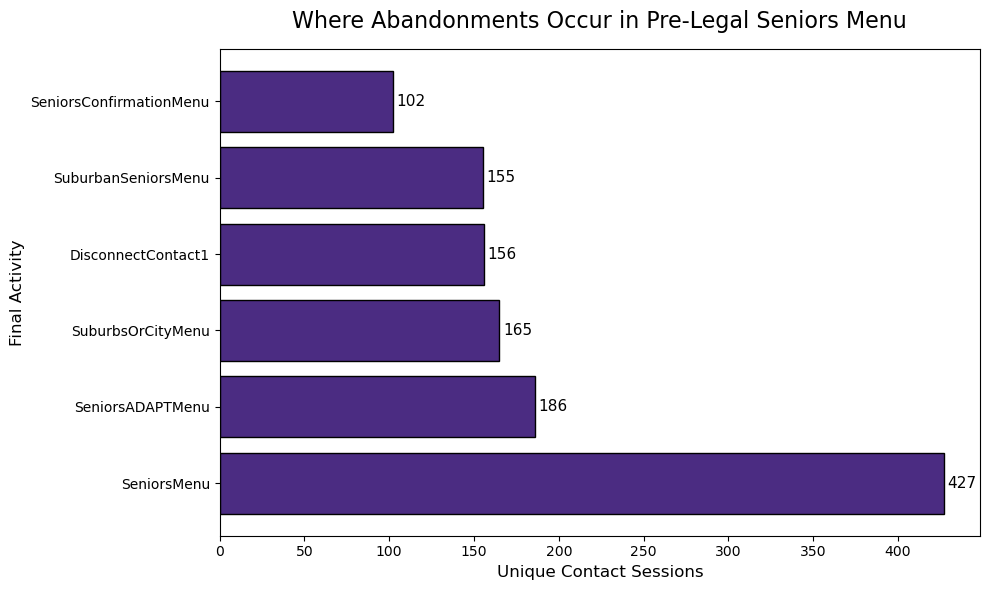

In [72]:
plt.figure(figsize=(10,6))

plt.barh(
    filtered_counts.index,
    filtered_counts.values,
    color='#4b2c82',
    edgecolor='black'
)

plt.title("Where Abandonments Occur in Pre-Legal Seniors Menu", fontsize=16, pad=15)
plt.xlabel("Unique Contact Sessions", fontsize=12)
plt.ylabel("Final Activity", fontsize=12)

# Add labels on bars
for i, (activity, count) in enumerate(filtered_counts.items()):
    plt.text(count + 2, i, str(count), va='center', fontsize=11)

plt.tight_layout()
plt.savefig("prelegal_seniors_abandonment_occurence.png", dpi=300, bbox_inches='tight')
plt.show()


In [73]:
filtered_counts.sum()

1191

In [74]:
427/1191

0.35852225020990763